# Análisis Exploratorio: Predicción de Argumentos Efectivos

CC3084 Data Science, Universidad del Valle de Guatemala, Semestre II 2026

Reto 19, Feedback Prize - Predicting Effective Arguments (Kaggle).

## Situación problemática

Los estudiantes de secundaria escriben ensayos argumentativos pero casi no reciben comentarios sobre ellos. Un profesor con 150 alumnos no alcanza a revisar párrafo por párrafo cuál idea está bien sustentada y cuál no. La retroalimentación llega tarde y es muy general.

Esto afecta más a los estudiantes de escuelas con menos recursos, que son los que menos acceso tienen a apoyo en escritura.

## Problema científico

¿Se puede clasificar de forma automática qué tan efectivo es un argumento dentro de un ensayo estudiantil, usando su texto y su función dentro del ensayo?

Cada fragmento del conjunto viene etiquetado con tres niveles de efectividad y siete tipos de argumento. Antes de modelar hay que ver qué separa un argumento bueno de uno malo.

## Objetivos

**General.** Describir el conjunto de datos de argumentos estudiantiles para identificar qué distingue a los fragmentos efectivos de los inefectivos.

**Específico 1.** Medir el desbalance entre clases de efectividad y tipos de argumento con tablas de frecuencia y proporciones.

**Específico 2.** Revisar si variables como longitud del texto y posición en el ensayo se relacionan con la efectividad.

**Específico 3.** Detectar datos faltantes, duplicados y valores atípicos, y documentar qué se decidió hacer con ellos.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

## 1. Carga y estructura de los datos

In [ ]:
ruta = '/kaggle/input/competitions/feedback-prize-effectiveness'
entrenamiento = pd.read_csv(f'{ruta}/train.csv')

print(entrenamiento.shape)
entrenamiento.head()

(36765, 5)


,discourse_id,essay_id,discourse_text,discourse_type,discourse_effectiveness
0,0013cc385424,007ACE74B050,"Hi, i'm Isaac, i'm going to be writing about how this face on Mars is a natural landform or if there is life on Mars...",Lead,Adequate
1,9704a709b505,007ACE74B050,"On my perspective, I think that the face is a natural landform because I dont think that there is any life on Mars. ...",Position,Adequate
2,c22adee811b6,007ACE74B050,I think that the face is a natural landform because there is no life on Mars that we have descovered yet,Claim,Adequate
3,a10d361e54e4,007ACE74B050,"If life was on Mars, we would know by now. The reason why I think it is a natural landform because, nobody live on M...",Evidence,Adequate
4,db3e453ec4e2,007ACE74B050,People thought that the face was formed by alieans because they thought that there was life on Mars.,Counterclaim,Adequate


In [ ]:
entrenamiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36765 entries, 0 to 36764
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   discourse_id             36765 non-null  object
 1   essay_id                 36765 non-null  object
 2   discourse_text           36765 non-null  object
 3   discourse_type           36765 non-null  object
 4   discourse_effectiveness  36765 non-null  object
dtypes: object(5)
memory usage: 1.4+ MB


In [ ]:
resumen = pd.DataFrame({
    'tipo': entrenamiento.dtypes.astype(str),
    'unicos': entrenamiento.nunique(),
    'nulos': entrenamiento.isnull().sum()
})
resumen

,tipo,unicos,nulos
discourse_id,object,36765,0
essay_id,object,4191,0
discourse_text,object,36691,0
discourse_type,object,7,0
discourse_effectiveness,object,3,0


**Las cinco columnas son de texto y ninguna es numérica.** `discourse_id` y `essay_id` son identificadores, `discourse_text` es el contenido del fragmento, y `discourse_type` y `discourse_effectiveness` son las dos categóricas del problema, con 7 y 3 categorías.

Para poder hacer estadística descriptiva hay que construir variables numéricas a partir del texto. Eso se hace en la sección 4.

In [ ]:
print('ensayos:', entrenamiento['essay_id'].nunique())
print('fragmentos por ensayo:', round(len(entrenamiento) / entrenamiento['essay_id'].nunique(), 2))
print('ids repetidos:', entrenamiento['discourse_id'].duplicated().sum())
print('filas repetidas:', entrenamiento.duplicated().sum())
print('textos repetidos:', entrenamiento['discourse_text'].duplicated().sum())

ensayos: 4191
fragmentos por ensayo: 8.77
ids repetidos: 0
filas repetidas: 0
textos repetidos: 74


**Los datos vienen completos.** Las 36,765 filas no tienen ningún valor faltante y no hay identificadores repetidos. Los 36,765 fragmentos salen de 4,191 ensayos, es decir 8.77 fragmentos por ensayo en promedio.

Hay 74 textos que aparecen más de una vez. Se revisan en la siguiente sección antes de decidir qué hacer con ellos.

## 2. Limpieza

El conjunto viene limpio, así que las operaciones son pocas. Se dejan documentadas de todas formas.

In [ ]:
entrenamiento['discourse_text'] = entrenamiento['discourse_text'].str.strip()

print('textos vacíos:', (entrenamiento['discourse_text'].str.len() == 0).sum())

entrenamiento['discourse_effectiveness'] = pd.Categorical(
    entrenamiento['discourse_effectiveness'],
    categories=['Ineffective', 'Adequate', 'Effective'],
    ordered=True
)

textos vacíos: 0


In [ ]:
repetidos = entrenamiento[entrenamiento['discourse_text'].duplicated(keep=False)]
repetidos[['essay_id', 'discourse_text', 'discourse_type', 'discourse_effectiveness']].sort_values('discourse_text').head(10)

,essay_id,discourse_text,discourse_type,discourse_effectiveness
27350,ADB68BCD2874,"""That's a lava dome that takes the form of an isolated mesa about the same height as the Face on Mars.""",Evidence,Adequate
26691,A602D45D22B2,"""That's a lava dome that takes the form of an isolated mesa about the same height as the Face on Mars.""",Evidence,Adequate
25391,942ECB176B3A,"At the most basic level, the electoral college is unfair to voters.",Position,Adequate
28835,C2BAF4ADA2CA,"At the most basic level, the electoral college is unfair to voters.",Claim,Adequate
28436,BB3A6C2D0B65,Big States,Claim,Adequate
20121,4CA37D113612,Big States,Claim,Ineffective
11285,CB66B685DAF6,I agree,Position,Adequate
3933,44E2726DA1B3,I agree,Position,Adequate
23698,7BE3FAF66A0C,I disagree.,Rebuttal,Adequate
13746,F6A92E43251E,I disagree.,Concluding Statement,Ineffective


**Los textos repetidos se conservan.** Al verlos de cerca son frases muy cortas y comunes como "I agree", "Big States" o "I disagree.", escritas por estudiantes distintos en ensayos distintos. No son errores de captura.

Además, el mismo texto a veces tiene etiquetas diferentes. "Big States" aparece una vez como `Adequate` y otra como `Ineffective`. Eso deja ver que la efectividad no depende solo de las palabras, sino también del contexto del ensayo donde está el fragmento.

## 3. Variables categóricas

In [ ]:
frecuencia_tipo = entrenamiento['discourse_type'].value_counts().to_frame('frecuencia')
frecuencia_tipo['porcentaje'] = (frecuencia_tipo['frecuencia'] / len(entrenamiento) * 100).round(2)
frecuencia_tipo

,frecuencia,porcentaje
discourse_type,,
Evidence,12105,32.93
Claim,11977,32.58
Position,4024,10.95
Concluding Statement,3351,9.11
Lead,2291,6.23
Counterclaim,1773,4.82
Rebuttal,1244,3.38


In [ ]:
frecuencia_efectividad = entrenamiento['discourse_effectiveness'].value_counts().to_frame('frecuencia')
frecuencia_efectividad['porcentaje'] = (frecuencia_efectividad['frecuencia'] / len(entrenamiento) * 100).round(2)
frecuencia_efectividad

,frecuencia,porcentaje
discourse_effectiveness,,
Adequate,20977,57.06
Effective,9326,25.37
Ineffective,6462,17.58


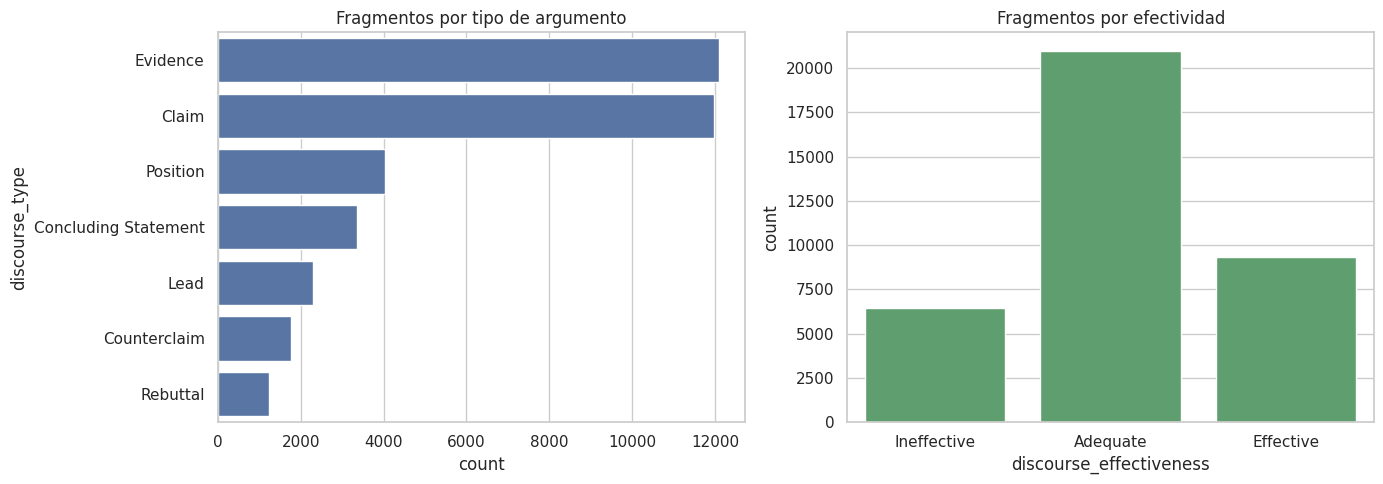

In [ ]:
orden_tipo = entrenamiento['discourse_type'].value_counts().index

figura, ejes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=entrenamiento, y='discourse_type', order=orden_tipo, ax=ejes[0], color='#4C72B0')
ejes[0].set_title('Fragmentos por tipo de argumento')

sns.countplot(data=entrenamiento, x='discourse_effectiveness', ax=ejes[1], color='#55A868')
ejes[1].set_title('Fragmentos por efectividad')

plt.tight_layout()
plt.show()

**Las dos variables están muy desbalanceadas.** En tipo de argumento, `Evidence` (32.93 %) y `Claim` (32.58 %) juntos son el 65.5 % del total, mientras que `Rebuttal` apenas llega al 3.38 %. La diferencia entre el tipo más común y el menos común es de casi 10 veces.

En efectividad, `Adequate` se lleva el 57.06 %, `Effective` el 25.37 % y `Ineffective` el 17.58 %.

Esto importa para el modelo. Predecir siempre `Adequate` acierta el 57 % de las veces sin aprender nada, así que la exactitud no sirve como métrica. La competencia usa log loss, que sí castiga las predicciones confiadas y equivocadas.